In [1]:
import os, sys
sys.path.append(os.path.abspath("F:/Neutrino_SI/Pycode"))  # 让 Python 能找到该目录的模块

(5000, 7)


<Figure size 1200x1200 with 0 Axes>

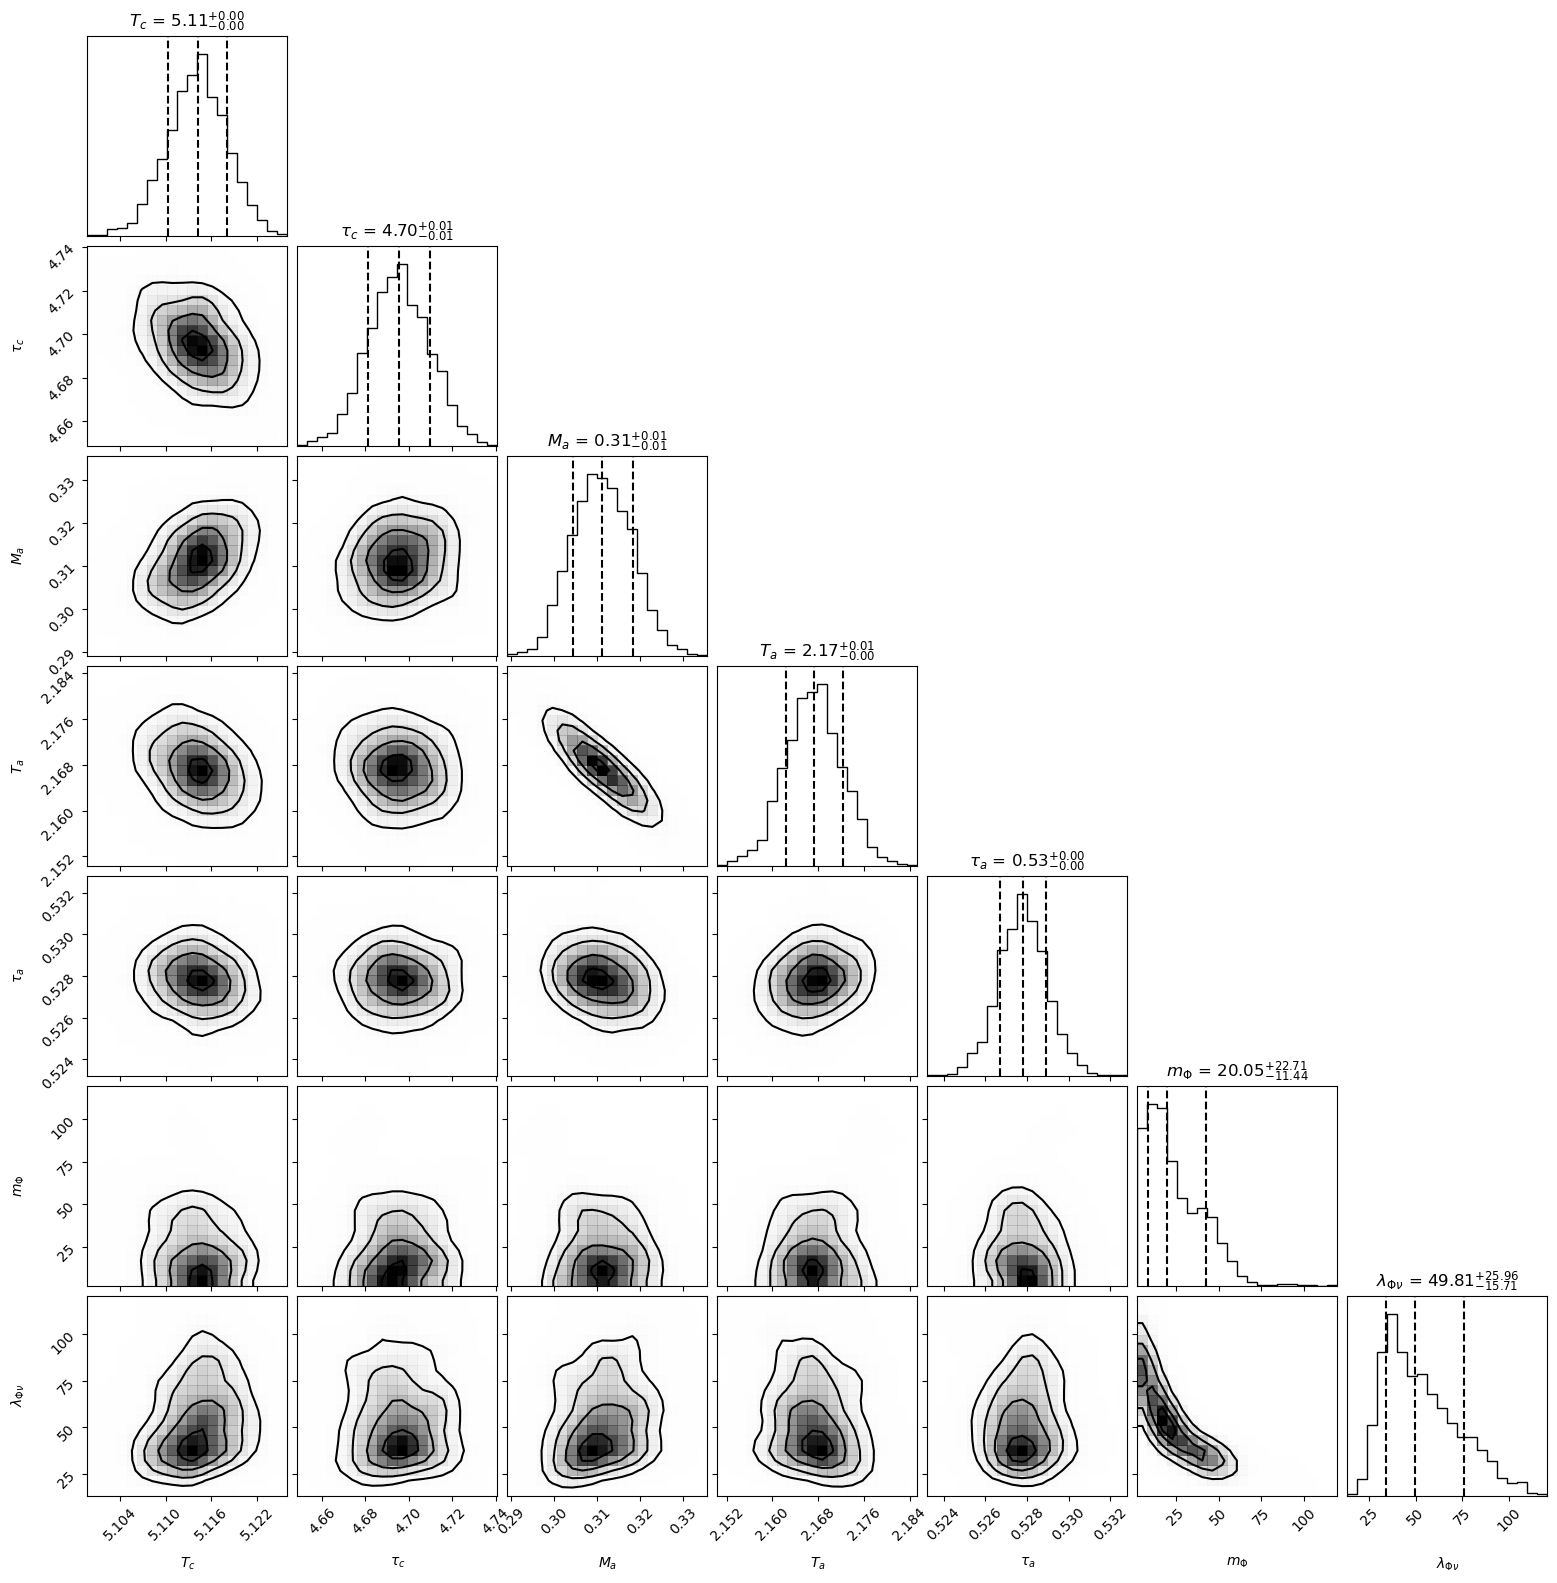

In [2]:
import corner
from Pycode import definition as df
import numpy as np
import matplotlib.pyplot as plt

labels = ['$T_c$', r'$\tau_c$' , '$M_a$','$T_a$', r'$\tau_a$', r'$m_{\Phi}$', r'${\lambda}_{\Phi \nu}$']
datax = []


datax= [df.readdata(i, 'F:/Neutrino_SI/Data/fixR12.xlsx') for i in range(len(labels))]
flat_samples = np.array(datax).transpose()
print(flat_samples.shape)


fig = plt.figure(figsize=(8, 8), dpi=150)        
fig = corner.corner(
            flat_samples, quantiles=[0.16, 0.5, 0.84],show_titles=True, title_kwargs={"fontsize": 12}, smooth = 1, labels=labels,
            plot_datapoints=False
        )

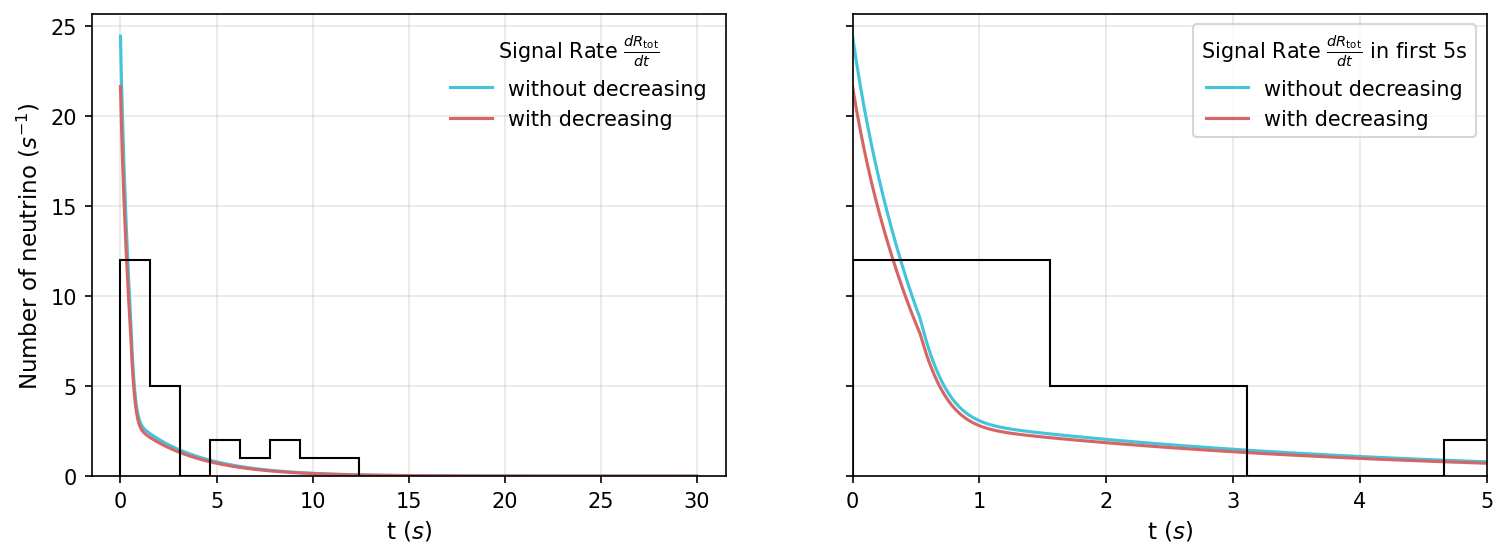

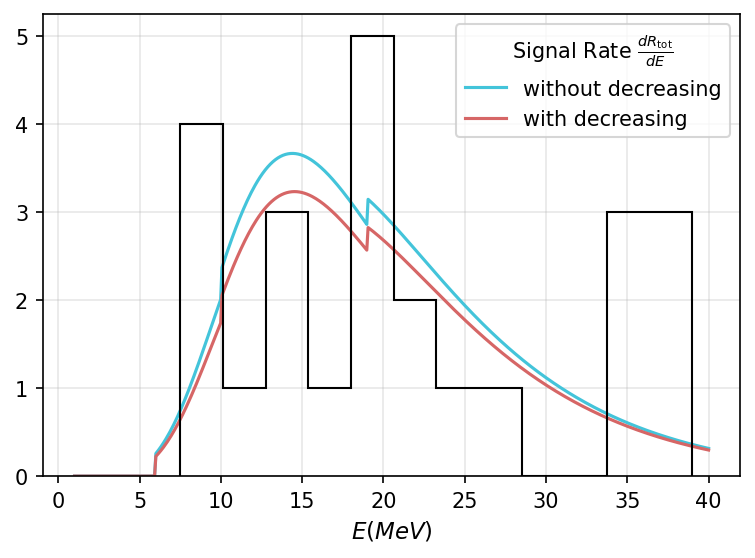

In [3]:
from Pycode import SignalRate
from Pycode import Data
from Pycode import definition as df
from cycler import cycler
from Pycode import Errors

tx = np.linspace(0, 30, 500)
tx_1 = np.linspace(0,5,500)
Ex = np.linspace(1,40,500)

fix_0 = [12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0]
fix_1 = [12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 97.296, 54.132]  # best fit six-parameter

# calculate SR_I(E_nu)

def SR_K_int(c, E, t, *theta):

    return SignalRate.SR_K(t, E, c, *theta)

def SR_I_int(c, E, t, *theta):

    return SignalRate.SR_I(t, E, c, *theta)

def SR_B_int(c, E, t, *theta):

    return SignalRate.SR_B(t, E, c, *theta)

t_hist = np.concatenate((Data.Kam_t, Data.IMB_t, Data.Baksan_t), axis=0)
E_hist = np.concatenate((Data.Kam_E, Data.IMB_E, Data.Baksan_E), axis=0)

yx_0 = df.gl2_integrate_vec(SR_K_int, [(-1, 1),(6, 100)], tx, args=fix_0) + df.gl2_integrate_vec(SR_I_int, [(-1, 1),(19, 100)], tx, args=fix_0) +df.gl2_integrate_vec(SR_B_int, [(-1, 1),(10, 100)], tx, args=fix_0)
yx_1 = df.gl2_integrate_vec(SR_K_int, [(-1, 1),(6, 100)], tx, args=fix_1) + df.gl2_integrate_vec(SR_I_int, [(-1, 1),(19, 100)], tx, args=fix_1) +df.gl2_integrate_vec(SR_B_int, [(-1, 1),(10, 100)], tx, args=fix_1)


yx_0_1 = df.gl2_integrate_vec(SR_K_int, [(-1, 1),(6, 100)], tx_1, args=fix_0) + df.gl2_integrate_vec(SR_I_int, [(-1, 1),(19, 100)], tx_1, args=fix_0) +df.gl2_integrate_vec(SR_B_int, [(-1, 1),(10, 100)], tx_1, args=fix_0)
yx_1_1 = df.gl2_integrate_vec(SR_K_int, [(-1, 1),(6, 100)], tx_1, args=fix_1) + df.gl2_integrate_vec(SR_I_int, [(-1, 1),(19, 100)], tx_1, args=fix_1) +df.gl2_integrate_vec(SR_B_int, [(-1, 1),(10, 100)], tx_1, args=fix_1)


def SR_E(c, t, E, *theta):

    return (np.where(E<=6, 0, SignalRate.SR_K(t, E, c, *theta))
            +np.where(E<=19, 0, SignalRate.SR_I(t, E, c, *theta))
            +np.where(E<=10, 0, SignalRate.SR_B(t, E, c, *theta)))

yx_E_0 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_0)
yx_E_1 = df.gl2_integrate_vec(SR_E,  [(-1, 1),(0, 30)], Ex, args=fix_1)


plt.rcParams.update({
    "figure.figsize": (6, 4), 
    "figure.dpi": 150,          
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,          
    "grid.alpha": 0.3,          
})

plt.rcParams["axes.prop_cycle"] = cycler(color=[
    "#43c4da", "#d66666", "#9467bd" ,"#90d239", "#ff7f0e",
    "#17becf", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"
])


fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True) 

ax[0].set_xlabel("t $(s)$")
ax[0].set_ylabel("Number of neutrino $(s^{-1})$")
ax[0].plot(tx, yx_0, label = 'without decreasing' )
ax[0].plot(tx, yx_1, label = 'with decreasing')
ax[0].hist(t_hist, bins=8, histtype="step", edgecolor="black", linewidth=1)
ax[0].legend(title=r"Signal Rate $\frac{dR_\mathrm{tot}}{dt}$", frameon=False)

ax[1].set_xlabel("t $(s)$")
ax[1].plot(tx_1, yx_0_1, label = 'without decreasing')
ax[1].plot(tx_1, yx_1_1, label = 'with decreasing')
ax[1].hist(t_hist, bins=8, histtype="step", edgecolor="black", linewidth=1)
ax[1].set_xlim(0, 5)
ax[1].legend(title=r"Signal Rate $\frac{dR_\mathrm{tot}}{dt}$ in first 5s", frameon=True)

counts, bin_edges = np.histogram(E_hist, bins=12)
bin_width = bin_edges[1] - bin_edges[0]
area_hist = np.sum(counts * bin_width)  
area_func = np.trapezoid(yx_E_0, Ex)  
scale_factor = area_hist / area_func

fig2, ax2 = plt.subplots()
ax2.set_xlabel("$E(MeV)$")
ax2.plot(Ex, yx_E_0* scale_factor, label = 'without decreasing')
ax2.plot(Ex, yx_E_1* scale_factor, label = 'with decreasing')
ax2.hist(E_hist, bins=12, histtype="step", edgecolor="black", linewidth=1)
ax2.legend(title=r"Signal Rate $\frac{dR_\mathrm{tot}}{dE}$", frameon=True)


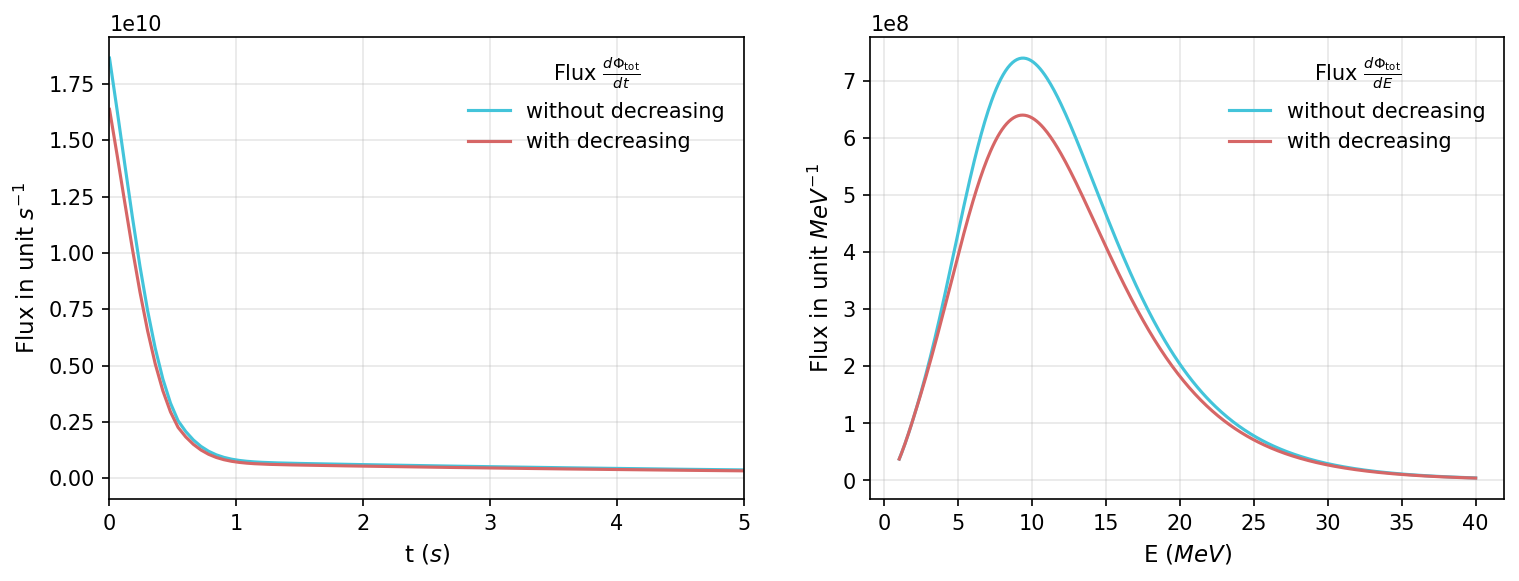

In [4]:
from scipy import integrate

def Flux_int_t(E, *theta):
    # D = 50*3.0856*1e21
    D=1
    return SignalRate.Flux_total(tx, E, *theta)


def Flux_int_E(t, *theta):
    # D = 50*3.0856*1e21
    D = 1
    return SignalRate.Flux_total(t, Ex, *theta)

Fx_0_t = integrate.quad_vec(Flux_int_t, 0, 100, args= (12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]
Fx_1_t = integrate.quad_vec(Flux_int_t, 0, 100, args= (12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 97.296, 54.132))[0]

Fx_0_E = integrate.quad_vec(Flux_int_E, 0, 30, args= (12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]
Fx_1_E = integrate.quad_vec(Flux_int_E, 0, 30, args= (12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 97.296, 54.132))[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))  
ax[0].set_xlabel("t $(s)$")
ax[0].set_ylabel("Flux in unit $s^{-1}$")
ax[0].set_xlim(0, 5)
ax[0].plot(tx, Fx_0_t, label = 'without decreasing' )
ax[0].plot(tx, Fx_1_t, label = 'with decreasing')
ax[0].legend(title=r"Flux $\frac{d\Phi_\mathrm{tot}}{dt}$", frameon=False)

ax[1].set_xlabel("E $(MeV)$")
ax[1].set_ylabel("Flux in unit $MeV^{-1}$")
ax[1].plot(Ex, Fx_0_E, label = 'without decreasing' )
ax[1].plot(Ex, Fx_1_E, label = 'with decreasing')
ax[1].legend(title=r"Flux $\frac{d\Phi_\mathrm{tot}}{dE}$", frameon=False)




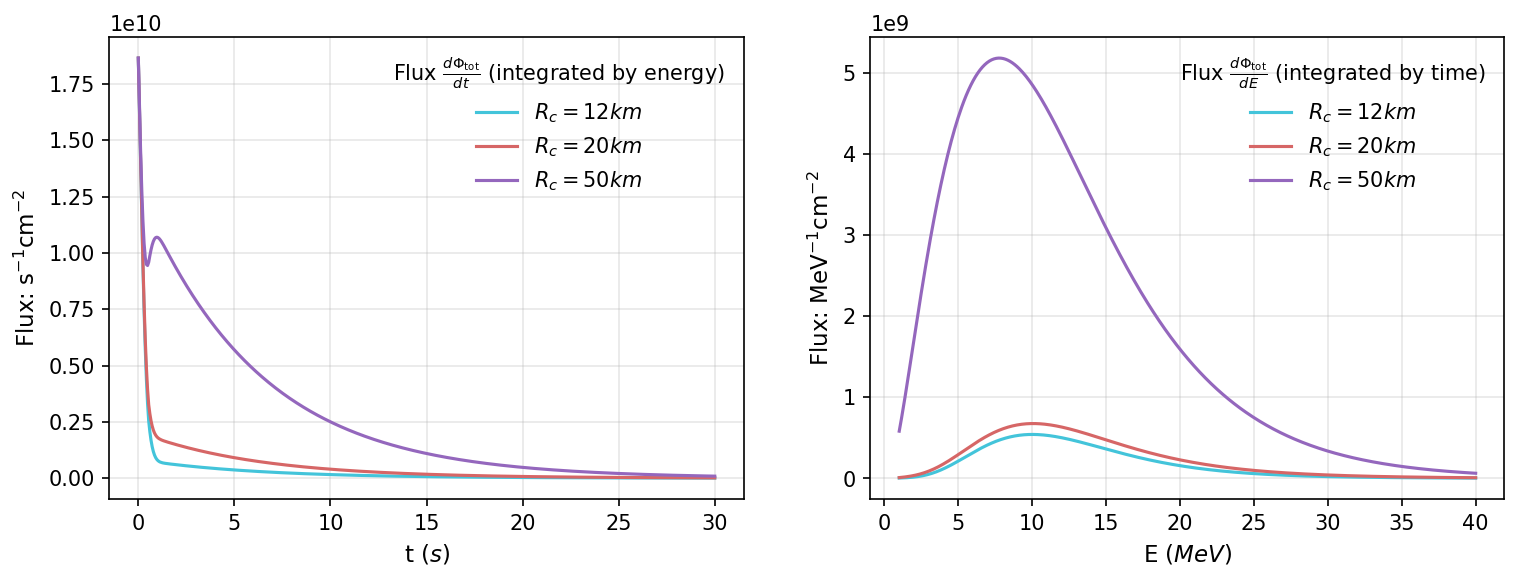

In [18]:
t_1= np.linspace(0, 3, 100)
E_1 = np.linspace(0.01, 40, 100)
t_range_12 = SignalRate.Flux_total(t_1, 10, 12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0)
t_range_20 = SignalRate.Flux_total(t_1, 10, 20, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0)
t_range_50 = SignalRate.Flux_total(t_1, 10, 50, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0)


E_range_12 = SignalRate.Flux_total(3, E_1, 12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0)
E_range_20 = SignalRate.Flux_total(3, E_1, 20, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0)
E_range_50 = SignalRate.Flux_total(3, E_1, 50, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0)

Fx_12_t = integrate.quad_vec(Flux_int_t, 0, 40, args= (12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]
Fx_20_t = integrate.quad_vec(Flux_int_t, 0, 40, args= (20, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]
Fx_50_t = integrate.quad_vec(Flux_int_t, 0, 40, args= (50, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]

Fx_12_E = integrate.quad_vec(Flux_int_E, 0, 3, args= (12.687, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]
Fx_20_E = integrate.quad_vec(Flux_int_E, 0, 3, args= (20, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]
Fx_50_E = integrate.quad_vec(Flux_int_E, 0, 30, args= (50, 5.035, 4.546, 0.309, 2.164, 0.533, 0, 0))[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))  
ax[0].set_xlabel("t $(s)$")
ax[0].set_ylabel(r"Flux: $\mathrm{s^{-1}cm^{-2}}$")
ax[0].plot(tx, Fx_12_t, label = '$R_c = 12km$' )
ax[0].plot(tx, Fx_20_t, label = '$R_c = 20km$' )
ax[0].plot(tx, Fx_50_t, label = '$R_c = 50km$' )

ax[0].legend(title=r"Flux $\frac{d\Phi_\mathrm{tot}}{dt}$ (integrated by energy)", frameon=False)

ax[1].set_xlabel("E $(MeV)$")
ax[1].set_ylabel(r"Flux: $\mathrm{MeV^{-1}cm^{-2}}$")
ax[1].plot(Ex, Fx_12_E, label = '$R_c = 12km$' )
ax[1].plot(Ex, Fx_20_E, label = '$R_c = 20km$' )
ax[1].plot(Ex, Fx_50_E, label = '$R_c = 50km$' )

ax[1].legend(title=r"Flux $\frac{d\Phi_\mathrm{tot}}{dE} $ (integrated by time)", frameon=False)

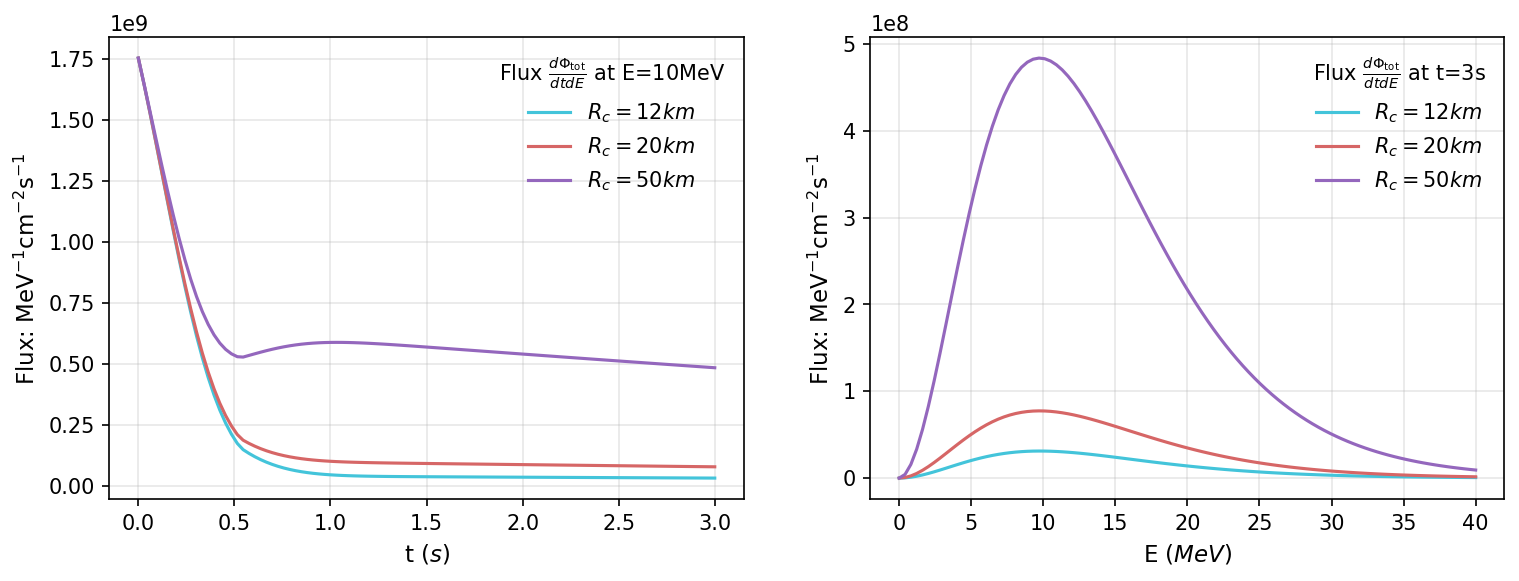

In [19]:


fig, ax = plt.subplots(1, 2, figsize=(12, 4))  
ax[0].set_xlabel("t $(s)$")
ax[0].set_ylabel(r"Flux: $\mathrm{MeV^{-1}cm^{-2}s^{-1}}$")
ax[0].plot(t_1, t_range_12, label = '$R_c = 12km$')
ax[0].plot(t_1, t_range_20, label = '$R_c = 20km$')
ax[0].plot(t_1, t_range_50, label = '$R_c = 50km$')
ax[0].legend(title=r"Flux $\frac{d\Phi_\mathrm{tot}}{dtdE}$ at E=10MeV", frameon=False)

ax[1].set_xlabel("E $(MeV)$")
ax[1].set_ylabel(r"Flux: $\mathrm{MeV^{-1}cm^{-2}s^{-1}}$")
ax[1].plot(E_1, E_range_12, label = '$R_c = 12km$')
ax[1].plot(E_1, E_range_20, label = '$R_c = 20km$')
ax[1].plot(E_1, E_range_50, label = '$R_c = 50km$')
ax[1].legend(title=r"Flux $\frac{d\Phi_\mathrm{tot}}{dtdE}$ at t=3s", frameon=False)
